In [2]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [3]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: STDC Network (Short-Term Dense Concatenate)
# Target Backbone: STDC1 / STDC2
# Target Dataset: CamVid
# Optimization Mode: Real-time Semantic Segmentation with Detail Guidance
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots (CamVid)
CAMVID_ROOT = Path("/home/ubuntu/miniconda3/envs/foggy/Dataset/CamVid")
TRAIN_DIR = CAMVID_ROOT / "train"
TRAIN_LABELS_DIR = CAMVID_ROOT / "train_labels"
VAL_DIR = CAMVID_ROOT / "val"
VAL_LABELS_DIR = CAMVID_ROOT / "val_labels"
TEST_DIR = CAMVID_ROOT / "test"
TEST_LABELS_DIR = CAMVID_ROOT / "test_labels"

# 2. Main Output Root
OUTPUT_DIR = Path("~/Pictures/stdc_camvid").expanduser()

FINAL_SAVE_DIR = OUTPUT_DIR / "Results_Export_stdc_camvid"
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals_stdc_camvid"

# 3. Local Working Directories
CHECKPOINT_DIR = OUTPUT_DIR / "progressive_checkpoints_stdc_camvid"
PLOTS_DIR = OUTPUT_DIR / "training_plots_stdc_camvid"
LOGS_DIR = OUTPUT_DIR / "training_logs_stdc_camvid"
METRICS_DIR = OUTPUT_DIR / "training_metrics_stdc_camvid"

# Safely build all target directories
for d in [OUTPUT_DIR, CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "STDC Network (Short-Term Dense Concatenate)"
MODEL_ALIAS = "STDC-Seg (Detail Guidance Enabled)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Custom Architecture Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_ce_loss": [],
    "train_detail_loss": [],  # Specific for STDC boundary guidance 
    
    # Training Metrics
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    
    # Validation Evaluation Metrics
    "val_total_loss": [], 
    "val_ce_loss": [],
    "val_detail_loss": [],    
    
    # Validation Metrics
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    
    # Optimizer State Records
    "backbone_lr": [],
    "head_lr": [],
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_stdc_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_stdc_checkpoint.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: STDC-Seg (Detail Guidance Enabled)
Custom Architecture Base: STDC Network (Short-Term Dense Concatenate)
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid
Checkpoints will be saved to: /home/ubuntu/Pictures/stdc_camvid/progressive_checkpoints_stdc_camvid
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [4]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: STDC Network (STDC1 / STDC2)
# Target Dataset: CamVid
# Optimization Mode: Real-time Segmentation with Detail Guidance
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path

print(f"Training Image root inherited: {TRAIN_DIR.resolve()}")
print(f"Training Mask root inherited : {TRAIN_LABELS_DIR.resolve()}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (CamVid 11-Class Standard)
# ------------------------------------------------------------
CLASSES = 11
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Sky", "Building", "Pole", "Road", "Pavement", 
    "Tree", "SignSymbol", "Fence", "Car", "Pedestrian", "Bicyclist"
]

# Standard CamVid RGB Color Palette
CAMVID_PALETTE = np.array([
    [128, 128, 128],  # 0: Sky
    [128, 0, 0],      # 1: Building
    [192, 192, 128],  # 2: Pole
    [128, 64, 128],   # 3: Road
    [60, 40, 222],    # 4: Pavement (Sidewalk)
    [128, 128, 0],    # 5: Tree
    [192, 128, 128],  # 6: SignSymbol
    [64, 64, 128],    # 7: Fence
    [64, 0, 128],     # 8: Car
    [64, 64, 0],      # 9: Pedestrian
    [0, 128, 192]     # 10: Bicyclist
], dtype=np.uint8)

# ------------------------------------------------------------
# STDC-SEG OPTIMIZATION SCHEDULE 
# ------------------------------------------------------------
BASE_LR = 0.01                # Standard initial learning rate
LR_POLICY = "poly"            # Poly learning rate policy
LR_POWER = 0.9                
WEIGHT_DECAY = 5e-4           
MOMENTUM = 0.9                

# CamVid specific resolutions (Native is 720x960)
TRAIN_CROP_SIZE = (720, 960)  
BATCH_SIZE = 12               # Adjusted for CamVid's standard real-time testing batch limits
GRAD_ACCUM_STEPS = max(1, 24 // BATCH_SIZE) # Accumulate to simulate larger batch sizes if needed

# CamVid is smaller than Cityscapes (only 367 training images).
# 10,000 iterations is the standard BiSeNet/STDC benchmark for CamVid.
MAX_ITERATIONS = 10000        
EPOCHS = 350                  # ~30 iterations per epoch at batch size 12. 350 * 30 ~ 10,500 iters
WARMUP_ITERATIONS = 1000      

print("\n--- STDC-SEG TRAINING CONFIGURATION (CAMVID) ---")
print(f"Total Training Epochs  : {EPOCHS} (~{MAX_ITERATIONS} iterations)")
print(f"Base Learning Rate     : {BASE_LR}")
print(f"Learning Rate Schedule : {LR_POLICY} (power {LR_POWER}) with Warmup ({WARMUP_ITERATIONS} iters)")
print(f"Weight Decay           : {WEIGHT_DECAY}")
print(f"Training Crop Size     : {TRAIN_CROP_SIZE}")
print(f"Effective Batch Size   : {BATCH_SIZE * GRAD_ACCUM_STEPS} (using Accumulation Steps: {GRAD_ACCUM_STEPS})")

# ------------------------------------------------------------
# LOSS SETTINGS (Semantic + Detail Guidance)
# ------------------------------------------------------------
USE_CROSS_ENTROPY = True
USE_OHEM = True               

print("\n--- Loss Formulation ---")
print("Primary: Cross-Entropy Loss with OHEM for Semantic Prediction")
print("Auxiliary: Detail Loss (Binary Cross-Entropy + Dice Loss) for Boundary Guidance")

# ------------------------------------------------------------
# LABEL ENCODING & DECODING (CamVid Specific)
# ------------------------------------------------------------
def encode_mask(mask_raw: np.ndarray) -> np.ndarray:
    """
    Robust mask encoder. Safely handles both raw RGB masks and 1D index masks.
    Ensures that any index >= 11 (including the standard CamVid void class) 
    is routed to the IGNORE_INDEX (255) to prevent PyTorch CUDA crashes.
    """
    # Check if the mask was loaded as an RGB image (Height, Width, 3)
    if len(mask_raw.shape) == 3 and mask_raw.shape[2] == 3:
        mask_out = np.full(mask_raw.shape[:2], IGNORE_INDEX, dtype=np.uint8)
        for idx, color in enumerate(CAMVID_PALETTE):
            # Find all pixels matching this color and assign the class index
            matches = np.all(mask_raw == color, axis=-1)
            mask_out[matches] = idx
        return mask_out
        
    # Otherwise, assume it is already a 1D index mask (Height, Width)
    else:
        mask = mask_raw.copy().astype(np.uint8)
        # Force all out-of-bounds classes (11+) to IGNORE_INDEX
        mask[mask >= CLASSES] = IGNORE_INDEX
        return mask

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    """
    Converts a 2D integer segmentation mask back into a 3D RGB image
    using the CamVid color palette.
    """
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CAMVID_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES 
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Plot 1: Total Loss Curve
    if len(history_dict.get("train_total_loss", [])) == len(epochs):
        axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    val_loss_arr = np.array(history_dict.get("val_total_loss", []))
    if len(val_loss_arr) == len(epochs) and not np.isnan(val_loss_arr).all() and not np.all(val_loss_arr == 0):
        axes[0].plot(epochs, val_loss_arr, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    # Plot 2: Detail Guidance Loss Curve
    if len(history_dict.get("train_detail_loss", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["train_detail_loss"], label='Train Detail Loss', color='purple', linewidth=2)
    axes[1].set_title('Detail Guidance Loss (Boundary Check)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=12)

    # Plot 3: mIoU Curve
    if len(history_dict.get("train_miou", [])) == len(epochs):
        axes[2].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict.get("val_miou", [])) == len(epochs):
        axes[2].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[2].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epochs', fontsize=12)
    axes[2].set_ylabel('mIoU (%)', fontsize=12)
    axes[2].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION (STDC Specific)
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    
    # Detail Head branch is discarded in the inference phase.
    model.eval() 

    batch = next(iter(loader))
    images, target_masks = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            # In eval mode, STDC returns only the segmentation logits (no detail maps)
            logits = model(images)
            
            # STDC upsamples the prediction straight back to input resolution natively
            if logits.shape[-2:] != (current_h, current_w):
                logits = F.interpolate(logits, size=(current_h, current_w), mode='bilinear', align_corners=True)
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = target_masks.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        # Denormalize Image (assuming standard ImageNet stats)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"STDC Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(list(TRAIN_DIR.rglob("*.png")))
train_masks = sorted(list(TRAIN_LABELS_DIR.rglob("*.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured for STDC-Seg CamVid Training.")

Training Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/CamVid/train
Training Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/CamVid/train_labels
Visualizations target: /home/ubuntu/Pictures/stdc_camvid/training_visuals_stdc_camvid
Final export target: /home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid

--- STDC-SEG TRAINING CONFIGURATION (CAMVID) ---
Total Training Epochs  : 350 (~10000 iterations)
Base Learning Rate     : 0.01
Learning Rate Schedule : poly (power 0.9) with Warmup (1000 iters)
Weight Decay           : 0.0005
Training Crop Size     : (720, 960)
Effective Batch Size   : 24 (using Accumulation Steps: 2)

--- Loss Formulation ---
Primary: Cross-Entropy Loss with OHEM for Semantic Prediction
Auxiliary: Detail Loss (Binary Cross-Entropy + Dice Loss) for Boundary Guidance
Discovered 369 images and 369 masks.
Step 2 fully configured for STDC-Seg CamVid Training.


In [5]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: STDC Network
# Target Dataset: CamVid
# Optimization Mode: Real-time Segmentation with Detail Guidance
# ============================================================

import os
import cv2
import inspect
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CAMVID
# ------------------------------------------------------------
def get_camvid_pairs(split):
    if split == "train":
        img_dir = TRAIN_DIR
        mask_dir = TRAIN_LABELS_DIR
    elif split == "val":
        img_dir = VAL_DIR
        mask_dir = VAL_LABELS_DIR
    elif split == "test":
        img_dir = TEST_DIR
        mask_dir = TEST_LABELS_DIR
    else:
        raise ValueError(f"Unknown split: {split}")
        
    if not img_dir.exists() or not mask_dir.exists():
        raise FileNotFoundError(f"CamVid directories not found. Check: {img_dir} or {mask_dir}")
        
    all_imgs = sorted(list(img_dir.rglob("*.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # CamVid labels typically have the exact same name as the image, 
        # or sometimes an '_L' suffix. We will check exact match first.
        mask_name = img_path.name
        mask_path = mask_dir / mask_name
        
        # Fallback for '_L.png' format if exact match fails
        if not mask_path.exists():
            mask_name = img_path.stem + "_L" + img_path.suffix
            mask_path = mask_dir / mask_name

        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
        else:
            print(f"Warning: No mask found for {img_path.name} at {mask_dir}")
            
    return valid_imgs, valid_masks

# Extract dataset paths
train_img_paths, train_mask_paths = get_camvid_pairs("train")
val_img_paths, val_mask_paths = get_camvid_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid CamVid image/mask pairs. Please check directory contents.")

print(f"\n--- CamVid Dataset Split (STDC-Seg) ---")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# CAMVID DATASET CLASS
# ------------------------------------------------------------
class CamVidSTDCDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # LOAD UNCHANGED: Prevents OpenCV from destroying RGB masks by flattening them to grayscale
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        # If the mask is 3-channel (RGB), OpenCV loaded it as BGR. Convert to RGB so our palette matches.
        if len(mask_raw.shape) == 3 and mask_raw.shape[2] == 3:
            mask_raw = cv2.cvtColor(mask_raw, cv2.COLOR_BGR2RGB)
            
        # Utilize the robust encode_mask function defined in Step 2 
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        return image, mask

# ------------------------------------------------------------
# AUGMENTATION PIPELINE 
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# Retrieve global CamVid crop size defined in Step 2 (720x960)
TRAIN_CROP_SIZE = globals().get("TRAIN_CROP_SIZE", (720, 960))
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)

train_transform = A.Compose([
    # Standard Real-Time Segmentation Augmentations (adapted from STDC paper)
    A.RandomScale(scale_limit=(-0.5, 0.5), interpolation=cv2.INTER_LINEAR, p=1.0),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1, p=0.5), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0), 
    A.HorizontalFlip(p=0.5), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation pipeline retains standard aspect ratio (native CamVid resolution)
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# INITIALIZATION & DATALOADERS
# ------------------------------------------------------------
train_dataset = CamVidSTDCDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = CamVidSTDCDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
BATCH_SIZE = globals().get("BATCH_SIZE", 12) 

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Micro-Batch Size    : {BATCH_SIZE}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS & CUDA ASSERTION PREVENTION
# ------------------------------------------------------------
train_images, train_masks = next(iter(train_loader))
print("\n--- STDC-Seg Train Batch Sanity Check ---")
print(f"Images tensor shape : {train_images.shape} (Expected: [B, 3, 720, 960])")
print(f"Masks tensor shape  : {train_masks.shape} (Expected: [B, 720, 960])")

val_images, val_masks = next(iter(val_loader))
print(f"Val images shape    : {val_images.shape} (Native CamVid Resolution: 720x960)")
print(f"Val masks shape     : {val_masks.shape}")

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"

# Definitively verify that the mask encoding worked
unique_vals = torch.unique(train_masks).tolist()
print(f"Unique mask pixel values in batch: {unique_vals}")

valid_classes = all(val in range(11) or val == 255 for val in unique_vals)
if valid_classes:
    print("SUCCESS: Mask is completely clean. Safe to launch training in Step 5.")
else:
    print("CRITICAL WARNING: Mask contains rogue values outside 0-10 or 255!")

print("\nStep 3 configured successfully for STDC-Seg on CamVid.")


--- CamVid Dataset Split (STDC-Seg) ---
Training image/mask pairs   : 369
Validation image/mask pairs : 100

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Micro-Batch Size    : 12

--- STDC-Seg Train Batch Sanity Check ---
Images tensor shape : torch.Size([12, 3, 720, 960]) (Expected: [B, 3, 720, 960])
Masks tensor shape  : torch.Size([12, 720, 960]) (Expected: [B, 720, 960])
Val images shape    : torch.Size([1, 3, 720, 960]) (Native CamVid Resolution: 720x960)
Val masks shape     : torch.Size([1, 720, 960])
Unique mask pixel values in batch: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 255]
SUCCESS: Mask is completely clean. Safe to launch training in Step 5.

Step 3 configured successfully for STDC-Seg on CamVid.


In [6]:
# ============================================================
# STEP 4: MODEL ARCHITECTURE, LOSS, OPTIMIZER, SCHEDULER
# Target Architecture: STDC Network (Short-Term Dense Concatenate)
# Target Dataset: CamVid (11 Classes)
# Optimization Mode: Real-time Segmentation with Detail Guidance
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

# ------------------------------------------------------------
# GLOBALS INHERITANCE (CamVid Specific)
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = 11
IGNORE_INDEX = 255
EPOCHS = globals().get("EPOCHS", 350)   # Approx 10,000 - 10,500 iterations total
BASE_LR = 0.01          
WEIGHT_DECAY = 5e-4     
MOMENTUM = 0.9          
WARMUP_ITERS = 1000     

# ------------------------------------------------------------
# STDC ARCHITECTURAL COMPONENTS
# ------------------------------------------------------------

class ConvBNReLU(nn.Module):
    """ConvX operation: Conv2d -> BatchNorm2d -> ReLU."""
    def __init__(self, in_chan, out_chan, ks=3, stride=1, padding=1):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_chan, out_chan, kernel_size=ks, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_chan)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class STDCModule(nn.Module):
    """
    Short-Term Dense Concatenate module (STDC module).
    Filter numbers decrease geometrically to reduce computation complexity.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(STDCModule, self).__init__()
        self.stride = stride
        
        c1 = out_channels // 2
        c2 = c1 // 2
        c3 = c2 // 2
        c4 = c3
        
        self.conv1 = ConvBNReLU(in_channels, c1, ks=1, stride=1, padding=0)
        self.conv2 = ConvBNReLU(c1, c2, ks=3, stride=stride, padding=1)
        self.conv3 = ConvBNReLU(c2, c3, ks=3, stride=1, padding=1)
        self.conv4 = ConvBNReLU(c3, c4, ks=3, stride=1, padding=1)
        
        if stride == 2:
            self.avg_pool = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        out1 = self.conv1(x)
        out2 = self.conv2(out1)
        out3 = self.conv3(out2)
        out4 = self.conv4(out3)
        
        if self.stride == 2:
            out1 = self.avg_pool(out1)
            
        out = torch.cat([out1, out2, out3, out4], dim=1)
        return out

class STDCNet(nn.Module):
    """STDC Backbone Encoder."""
    def __init__(self, backbone_type='stdc1'):
        super(STDCNet, self).__init__()
        
        if backbone_type == 'stdc1':
            block_repeats = [2, 2, 2]
        elif backbone_type == 'stdc2':
            block_repeats = [4, 5, 3]
        else:
            raise ValueError("backbone_type must be 'stdc1' or 'stdc2'")
            
        self.stage1 = ConvBNReLU(3, 32, ks=3, stride=2, padding=1)
        self.stage2 = ConvBNReLU(32, 64, ks=3, stride=2, padding=1)
        self.stage3 = self._make_stage(64, 256, block_repeats[0], stride=2)
        self.stage4 = self._make_stage(256, 512, block_repeats[1], stride=2)
        self.stage5 = self._make_stage(512, 1024, block_repeats[2], stride=2)

    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        layers = [STDCModule(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(STDCModule(out_channels, out_channels, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        feat2 = self.stage2(self.stage1(x))
        feat3 = self.stage3(feat2)
        feat4 = self.stage4(feat3)
        feat5 = self.stage5(feat4)
        return feat3, feat4, feat5

class AttentionRefineModule(nn.Module):
    """Attention Refine module (ARM) to refine deep context features."""
    def __init__(self, in_channels, out_channels):
        super(AttentionRefineModule, self).__init__()
        self.conv = ConvBNReLU(in_channels, out_channels, ks=3, stride=1, padding=1)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat = self.conv(x)
        attn = self.attention(feat)
        return torch.mul(feat, attn)

class FeatureFusionModule(nn.Module):
    """Feature Fusion module (FFM) to fuse low-level and context features."""
    def __init__(self, in_channels, out_channels):
        super(FeatureFusionModule, self).__init__()
        self.conv1 = ConvBNReLU(in_channels, out_channels, ks=1, stride=1, padding=0)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x1, x2):
        feat = torch.cat([x1, x2], dim=1)
        feat = self.conv1(feat)
        attn = self.attention(feat)
        return feat + torch.mul(feat, attn)

class STDCSegmentation(nn.Module):
    """Full STDC Segmentation Network with single-stream Detail Guidance."""
    def __init__(self, num_classes=11, backbone_type='stdc1'):
        super(STDCSegmentation, self).__init__()
        self.backbone = STDCNet(backbone_type=backbone_type)
        
        self.arm4 = AttentionRefineModule(512, 128)
        self.arm5 = AttentionRefineModule(1024, 128)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.conv_global = ConvBNReLU(1024, 128, ks=1, stride=1, padding=0)
        
        # Detail Head attached to Stage 3
        self.detail_head = nn.Sequential(
            ConvBNReLU(256, 64, ks=3, stride=1, padding=1),
            nn.Conv2d(64, 1, kernel_size=1)
        )
        
        self.ffm = FeatureFusionModule(256 + 128, 256)
        
        self.seg_head = nn.Sequential(
            ConvBNReLU(256, 256, ks=3, stride=1, padding=1),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_size = x.size()[2:]
        
        feat3, feat4, feat5 = self.backbone(x)
        
        if self.training:
            detail_out = self.detail_head(feat3)
            detail_out = F.interpolate(detail_out, size=input_size, mode='bilinear', align_corners=True)
            
        global_context = self.global_pool(feat5)
        global_context = self.conv_global(global_context)
        global_context = F.interpolate(global_context, size=feat5.size()[2:], mode='bilinear', align_corners=True)
        
        arm5_out = self.arm5(feat5)
        arm5_out = arm5_out + global_context
        arm5_out = F.interpolate(arm5_out, size=feat4.size()[2:], mode='bilinear', align_corners=True)
        
        arm4_out = self.arm4(feat4)
        context_out = arm4_out + arm5_out
        context_out = F.interpolate(context_out, size=feat3.size()[2:], mode='bilinear', align_corners=True)
        
        fused = self.ffm(feat3, context_out)
        
        seg_out = self.seg_head(fused)
        seg_out = F.interpolate(seg_out, size=input_size, mode='bilinear', align_corners=True)
        
        if self.training:
            return seg_out, detail_out
        return seg_out

# Initialize Model
model = STDCSegmentation(num_classes=CLASSES, backbone_type='stdc1').to(DEVICE)
print(f"Initialized STDC-Seg Model with Detail Guidance Branch for {CLASSES} classes.")

# ------------------------------------------------------------
# LOSS FORMULATION (OHEM + Detail Loss)
# ------------------------------------------------------------

class OHEMCrossEntropyLoss(nn.Module):
    """Cross-entry loss with Online Hard Example Mining (OHEM)."""
    def __init__(self, ignore_index=255, thresh=0.7, min_kept=100000):
        super(OHEMCrossEntropyLoss, self).__init__()
        self.ignore_index = ignore_index
        self.thresh = float(thresh)
        self.min_kept = int(min_kept)
        self.criterion = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, preds, targets):
        pixel_losses = self.criterion(preds, targets).view(-1)
        pixel_losses = pixel_losses[targets.view(-1) != self.ignore_index]
        
        if pixel_losses.numel() < self.min_kept:
            return pixel_losses.mean()
            
        sort_losses, _ = pixel_losses.sort(descending=True)
        keep_mask = sort_losses > self.thresh
        if keep_mask.sum() < self.min_kept:
            return sort_losses[:self.min_kept].mean()
        else:
            return sort_losses[keep_mask].mean()

class DetailLoss(nn.Module):
    """
    Binary cross-entropy and dice loss to jointly optimize the detail learning.
    """
    def __init__(self):
        super(DetailLoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
        
    def forward(self, preds, targets):
        # BCE Loss
        bce = self.bce_loss(preds, targets)
        
        # Dice Loss with Laplace smoothing item epsilon=1
        preds_sigmoid = torch.sigmoid(preds)
        intersection = 2 * torch.sum(preds_sigmoid * targets)
        union = torch.sum(preds_sigmoid ** 2) + torch.sum(targets ** 2)
        dice = 1.0 - (intersection + 1.0) / (union + 1.0)
        
        return bce + dice

class LaplacianDetailGenerator(nn.Module):
    """
    Generates binary detail ground-truth from semantic segmentation ground-truth 
    using a Laplacian operator.
    """
    def __init__(self):
        super(LaplacianDetailGenerator, self).__init__()
        laplacian_kernel = torch.tensor([[-1, -1, -1],
                                         [-1,  8, -1],
                                         [-1, -1, -1]], dtype=torch.float32)
        self.kernel = laplacian_kernel.view(1, 1, 3, 3).to(DEVICE)

    def forward(self, masks):
        # PREVENT VOID ARTIFACTS: Convert IGNORE_INDEX to 0 locally so it doesn't 
        # trigger massive artificial boundary gradients in the Laplacian operator.
        masks_clean = masks.clone()
        masks_clean[masks_clean == IGNORE_INDEX] = 0
        
        masks_float = masks_clean.unsqueeze(1).float()
        
        # Apply laplacian
        boundary = F.conv2d(masks_float, self.kernel, padding=1)
        boundary = boundary.clamp(min=0)
        boundary[boundary > 0] = 1.0
        return boundary

semantic_criterion = OHEMCrossEntropyLoss(ignore_index=IGNORE_INDEX).to(DEVICE)
detail_criterion = DetailLoss().to(DEVICE)
detail_generator = LaplacianDetailGenerator().to(DEVICE)

def compute_loss(outputs, targets):
    """Computes joint Semantic OHEM Loss + Detail Guidance Loss."""
    seg_out, detail_out = outputs
    
    # Primary segmentation loss
    loss_seg = semantic_criterion(seg_out, targets)
    
    # Generate detail ground truth dynamically
    with torch.no_grad():
        detail_gt = detail_generator(targets)
        
    # Auxiliary boundary detail loss
    loss_detail = detail_criterion(detail_out, detail_gt)
    
    total_loss = loss_seg + loss_detail
    return total_loss, loss_seg, loss_detail

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------
# SGD with momentum 0.9 and weight decay 5e-4
optimizer = optim.SGD(
    model.parameters(), 
    lr=BASE_LR, 
    momentum=MOMENTUM, 
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# SCHEDULER ("Poly" Policy with Warmup)
# ------------------------------------------------------------
try:
    steps_per_epoch = len(train_loader)
except NameError:
    # CamVid train split has ~367 images
    steps_per_epoch = 367 // globals().get("BATCH_SIZE", 12)

total_steps = steps_per_epoch * EPOCHS

def lr_scheduler_fn(current_step):
    """
    Combines warmup strategy for the first 1000 iterations 
    with a poly learning rate policy (power=0.9).
    """
    if current_step < WARMUP_ITERS:
        # Linear warmup from ~0.1 * BASE_LR to BASE_LR
        alpha = current_step / WARMUP_ITERS
        return 0.1 + 0.9 * alpha
    else:
        # Poly policy
        progress = (current_step - WARMUP_ITERS) / (total_steps - WARMUP_ITERS)
        return (1.0 - progress) ** 0.9

scheduler = LambdaLR(optimizer, lr_lambda=lr_scheduler_fn)

print("Optimization pipeline ready. STDC losses (OHEM + Detail) and Poly/Warmup LR scheduler initialized.")

Initialized STDC-Seg Model with Detail Guidance Branch for 11 classes.
Optimization pipeline ready. STDC losses (OHEM + Detail) and Poly/Warmup LR scheduler initialized.


In [7]:
# ============================================================
# STEP 5: TRAINING LOOP
# Target Architecture: STDC Network (Short-Term Dense Concatenate)
# Target Dataset: CamVid (11 Classes)
# Optimization Mode: Real-time Segmentation with Detail Guidance
# ============================================================

import os
import gc
import time
from datetime import timedelta
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# CamVid specific defaults
CLASSES = globals().get("CLASSES", 11)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
EPOCHS = globals().get("EPOCHS", 350) 
MIN_DELTA_MIOU = 0.001

scaler = GradScaler("cuda", enabled=USE_AMP)

# Global variables recovery
best_record = globals().get("best_record", {
    "epoch": -1, "best_epoch": -1, "best_miou": -1.0, 
    "best_macc": -1.0, "best_aacc": -1.0, 
    "best_path": str(CHECKPOINT_DIR / "best_miou_stdc_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_stdc_checkpoint.pt")
})

# Grab existing history or create a new one
history = globals().get("history", {})

# Safely ensure all required STDC keys exist
required_keys = [
    "epoch", "train_total_loss", "train_ce_loss", "train_detail_loss", 
    "val_total_loss", "train_miou", "val_miou", "val_macc", "val_aacc", 
    "learning_rate", "epoch_time_sec"
]
for k in required_keys:
    if k not in history:
        history[k] = []

# ------------------------------------------------------------
# METRICS HELPERS
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc)}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
cumulative_training_time_sec = 0.0 

latest_ckpt_path = best_record["latest_path"]

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
else:
    print("No previous checkpoint found. Starting fresh.")

print(f"\n--- Launching STDC-Seg Training Pipeline (CamVid) ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_ce_loss_sum = 0.0
    train_detail_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for images, masks in train_pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
            # In training mode, STDC returns both semantic logits and detail guidance maps
            outputs = model(images)
            loss, loss_seg, loss_detail = compute_loss(outputs, masks)

        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        global_update_step += 1

        train_loss_sum += loss.detach().item()
        train_ce_loss_sum += loss_seg.detach().item()
        train_detail_loss_sum += loss_detail.detach().item()
        train_batches += 1

        with torch.no_grad():
            seg_out = outputs[0] # The primary segmentation output
            preds_np = torch.argmax(seg_out, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        current_lr = get_current_lr(optimizer)
        train_pbar.set_postfix(
            Total=f"{train_loss_sum / train_batches:.3f}", 
            Seg=f"{train_ce_loss_sum / train_batches:.3f}",
            Det=f"{train_detail_loss_sum / train_batches:.3f}",
            lr=f"{current_lr:.2e}"
        )

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_loss_sum / max(1, train_batches)
    train_ce_loss_avg = train_ce_loss_sum / max(1, train_batches)
    train_detail_loss_avg = train_detail_loss_sum / max(1, train_batches)

    # ------------------------------------------------------------
    # VALIDATION LOOP
    # ------------------------------------------------------------
    # The detail branch is discarded during inference
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
                # Only segmentation logits are returned in eval mode
                logits = model(images)
                
                # Directly compute standard OHEM Cross-Entropy as validation loss (No Detail Loss)
                v_loss = semantic_criterion(logits, masks)
                
            val_loss_sum += v_loss.detach().item()
            val_batches += 1

            preds_np = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%")

    val_total_loss = val_loss_sum / max(1, val_batches)
    val_metrics = compute_metrics(val_conf_matrix)

    # Time tracking and ETA
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    epochs_processed_this_run = (epoch - start_epoch + 1)
    avg_epoch_time = cumulative_training_time_sec / max(1, epochs_processed_this_run)
    remaining_epochs = EPOCHS - epoch
    eta_seconds = remaining_epochs * avg_epoch_time
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    # Update History
    history["epoch"].append(epoch)
    history["train_total_loss"].append(train_total_loss)
    history["train_ce_loss"].append(train_ce_loss_avg)
    history["train_detail_loss"].append(train_detail_loss_avg)
    history["val_total_loss"].append(val_total_loss)
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["learning_rate"].append(current_lr)
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} (Seg: {train_ce_loss_avg:.4f}, Det: {train_detail_loss_avg:.4f}) | Train mIoU: {train_metrics['mIoU']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU']*100:.2f}% | Val aAcc:   {val_metrics['aAcc']*100:.2f}%\n"
        f"Learning Rate: {current_lr:.2e}"
    )

    # ------------------------------------------------------------
    # QUALITATIVE VISUALIZATION SAVING
    # ------------------------------------------------------------
    save_visuals_every_10_epochs(epoch, val_loader, model, save_path=QUAL_VIS_DIR, max_images=3)

    # ------------------------------------------------------------
    # DUAL-CHECKPOINTING SYSTEM
    # ------------------------------------------------------------
    ckpt_dict = {
        "epoch": epoch, 
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), 
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), 
        "best_record": best_record,
        "history": history, 
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    # Checkpoint 1: Save Latest State
    torch.save(ckpt_dict, latest_ckpt_path)

    # Checkpoint 2: Save Best Model
    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        torch.save(ckpt_dict, best_record["best_path"])
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

print(f"\n--- STDC-Seg Training Complete ---")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics

No previous checkpoint found. Starting fresh.

--- Launching STDC-Seg Training Pipeline (CamVid) ---
Target Epochs: 350 (Currently at 1)



Epoch 1/350 | Epoch Time: 54.14s | ETA: 5:14:54
Train Loss: 3.0946 (Seg: 1.8473, Det: 1.2473) | Train mIoU: 14.62%
Val Loss:   2.2477 | Val mIoU:   10.63% | Val aAcc:   50.04%
Learning Rate: 1.27e-03
[*] New Best Validation mIoU: 10.63% saved securely to disk.



Epoch 2/350 | Epoch Time: 19.50s | ETA: 3:33:33
Train Loss: 2.5651 (Seg: 1.5672, Det: 0.9979) | Train mIoU: 21.81%
Val Loss:   1.4343 | Val mIoU:   14.86% | Val aAcc:   56.45%
Learning Rate: 1.54e-03
[*] New Best Validation mIoU: 14.86% saved securely to disk.



Epoch 3/350 | Epoch Time: 19.56s | ETA: 2:59:39
Train Loss: 2.4301 (Seg: 1.4868, Det: 0.9433) | Train mIoU: 25.32%
Val Loss:   1.3027 | Val mIoU:   29.45% | Val aAcc:   80.78%
Learning Rate: 1.81e-03
[*] New Best Validation mIoU: 29.45% saved securely to disk.



Epoch 4/350 | Epoch Time: 19.55s | ETA: 2:42:32
Train Loss: 2.3580 (Seg: 1.4394, Det: 0.9187) | Train mIoU: 28.79%
Val Loss:   2.4813 | Val mIoU:   14.74% | Val aAcc:   41.10%
Learning Rate: 2.08e-03


...


Epoch 346/350 | Epoch Time: 19.06s | ETA: 0:01:17
Train Loss: 1.5125 (Seg: 0.8219, Det: 0.6907) | Train mIoU: 75.10%
Val Loss:   0.8202 | Val mIoU:   67.39% | Val aAcc:   95.01%
Learning Rate: 1.96e-04



Epoch 347/350 | Epoch Time: 19.44s | ETA: 0:00:58
Train Loss: 1.5123 (Seg: 0.8259, Det: 0.6864) | Train mIoU: 75.09%
Val Loss:   0.8196 | Val mIoU:   67.69% | Val aAcc:   95.22%
Learning Rate: 1.51e-04



Epoch 348/350 | Epoch Time: 19.50s | ETA: 0:00:38
Train Loss: 1.5131 (Seg: 0.8258, Det: 0.6873) | Train mIoU: 75.32%
Val Loss:   0.8199 | Val mIoU:   67.63% | Val aAcc:   95.27%
Learning Rate: 1.05e-04



Epoch 349/350 | Epoch Time: 19.65s | ETA: 0:00:19
Train Loss: 1.5153 (Seg: 0.8241, Det: 0.6912) | Train mIoU: 75.43%
Val Loss:   0.8214 | Val mIoU:   67.44% | Val aAcc:   95.05%
Learning Rate: 5.62e-05



Epoch 350/350 | Epoch Time: 19.55s | ETA: 0:00:00
Train Loss: 1.5111 (Seg: 0.8178, Det: 0.6933) | Train mIoU: 75.48%
Val Loss:   0.8210 | Val mIoU:   67.50% | Val aAcc:   95.20%
Learning Rate: 0.00e+00

--- STDC-Seg Training Complete ---
Best Epoch: 230 | Best mIoU: 68.19%


[*] Final export directory validated: /home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid



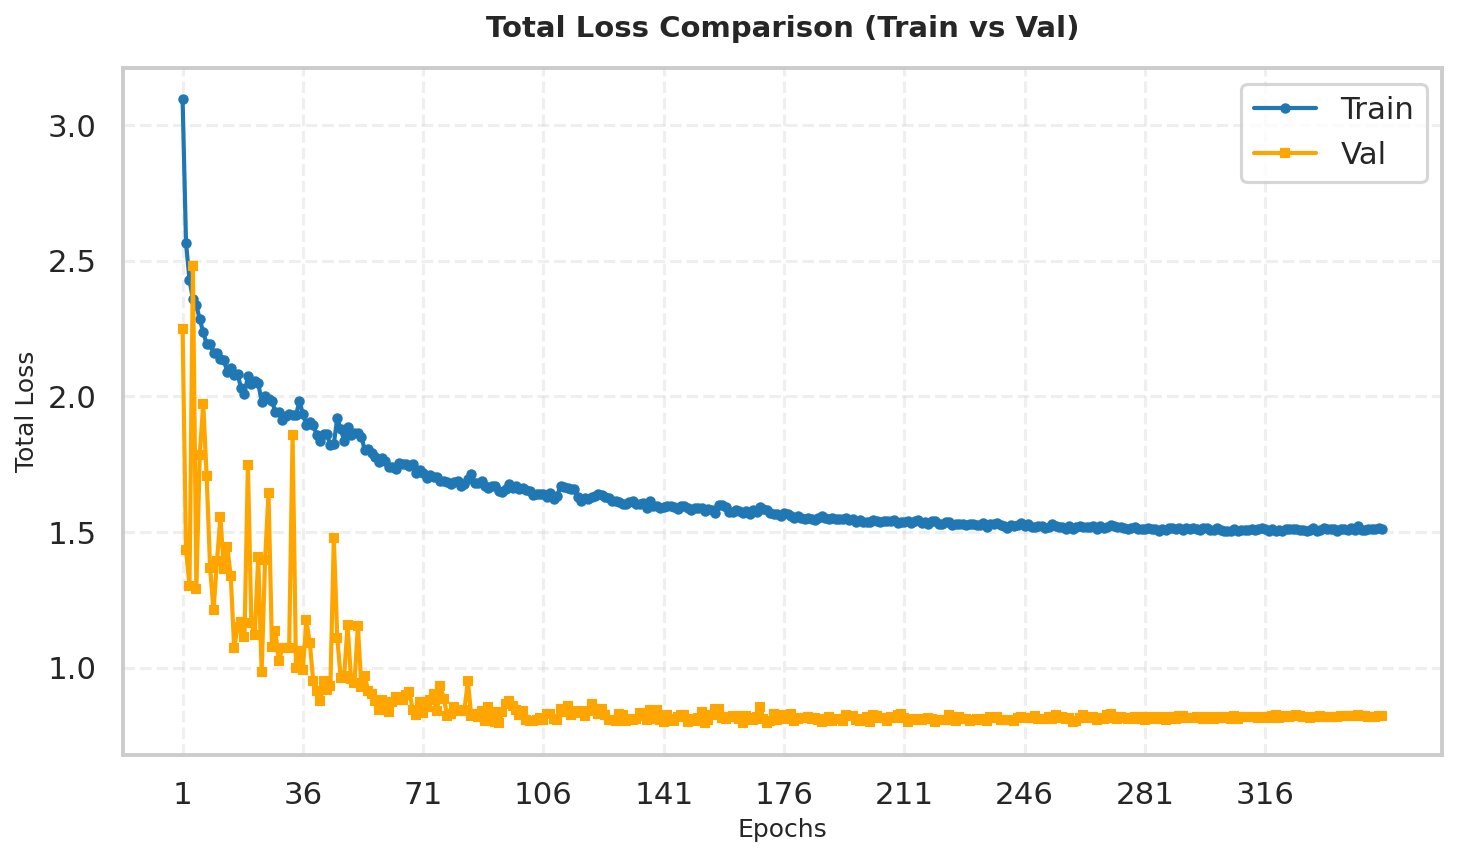

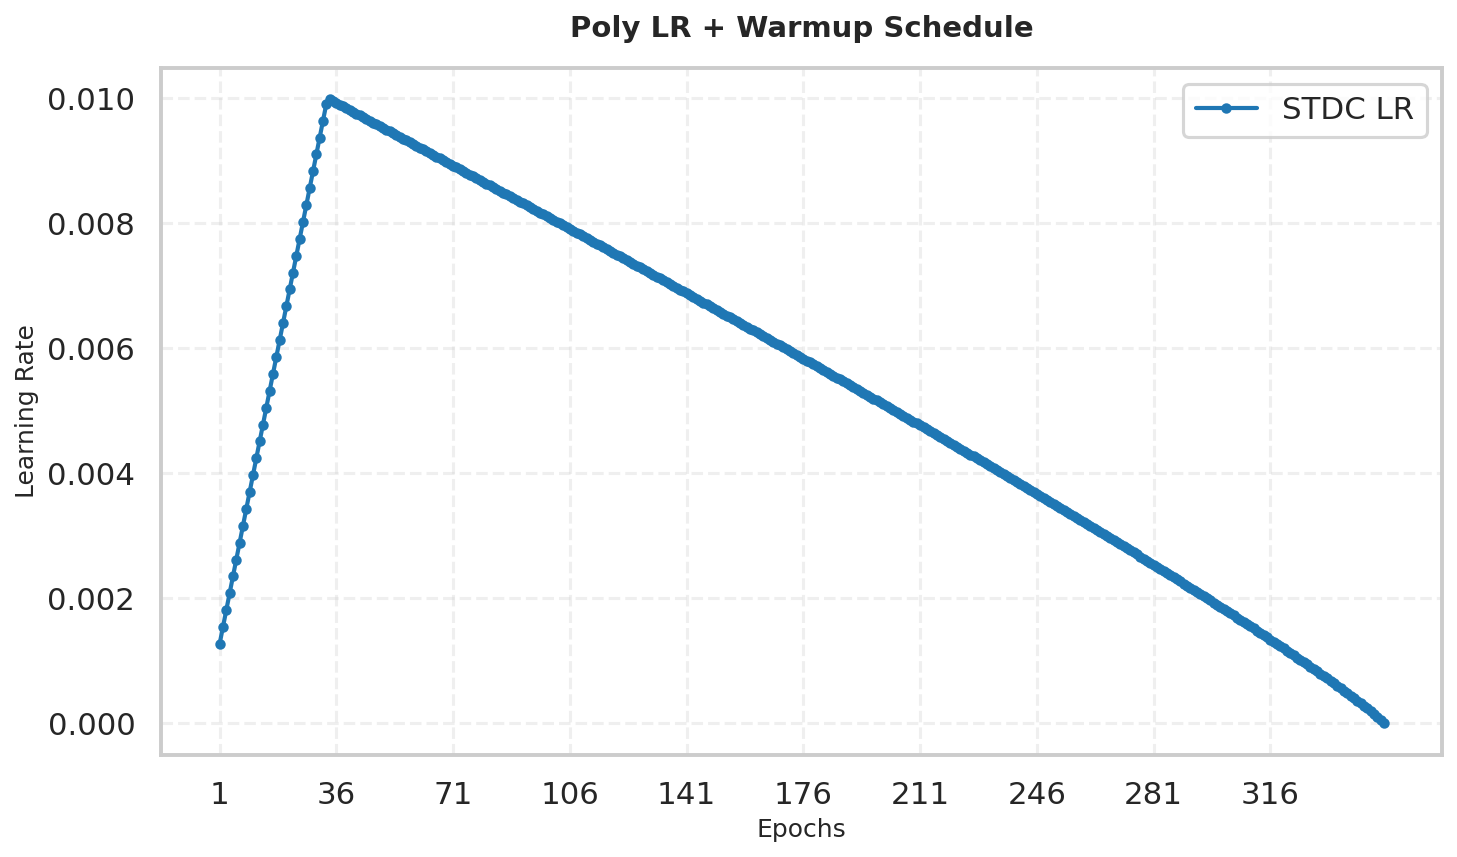

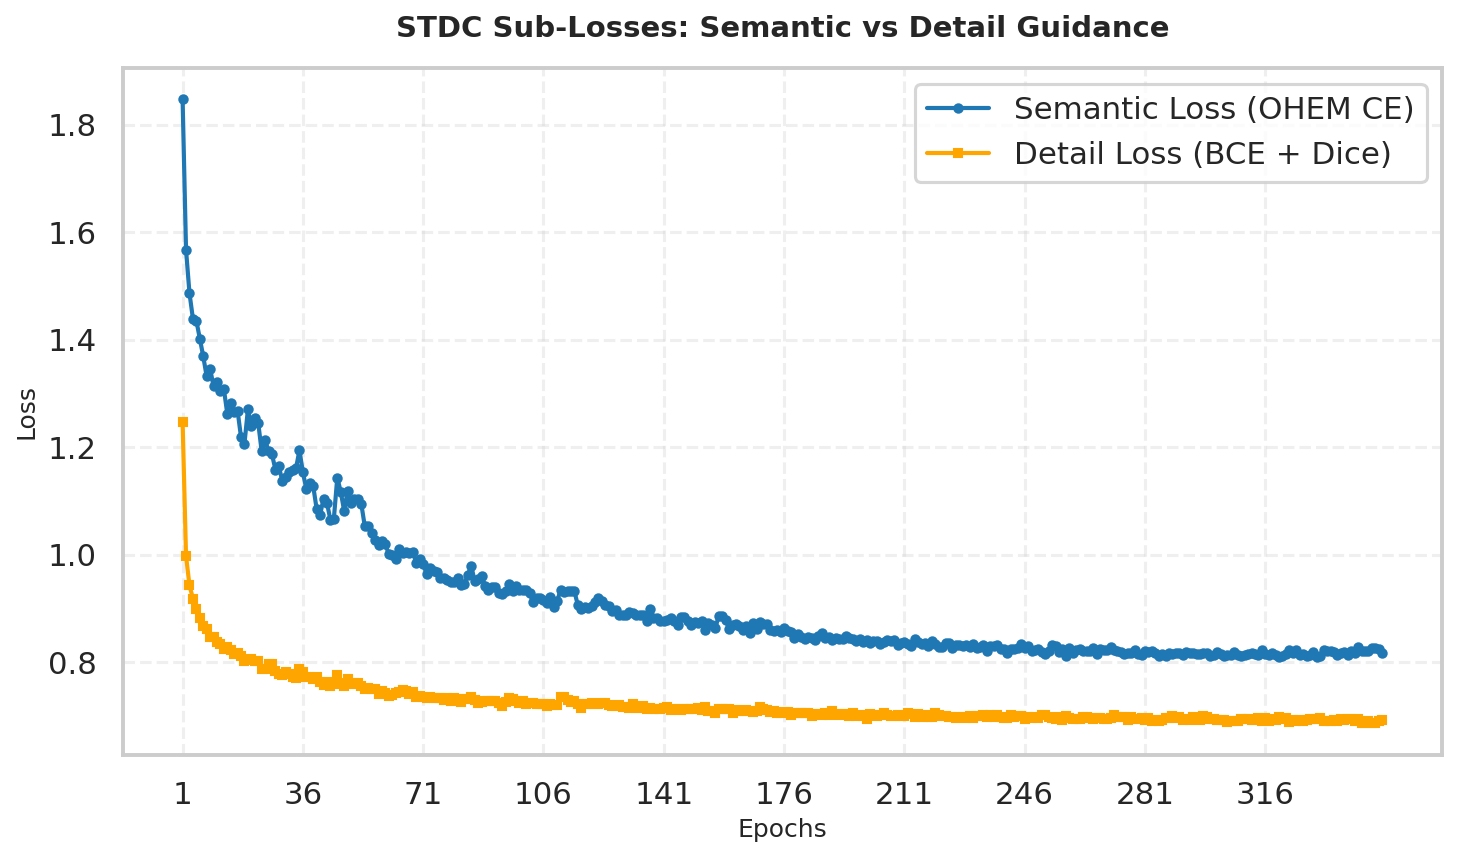

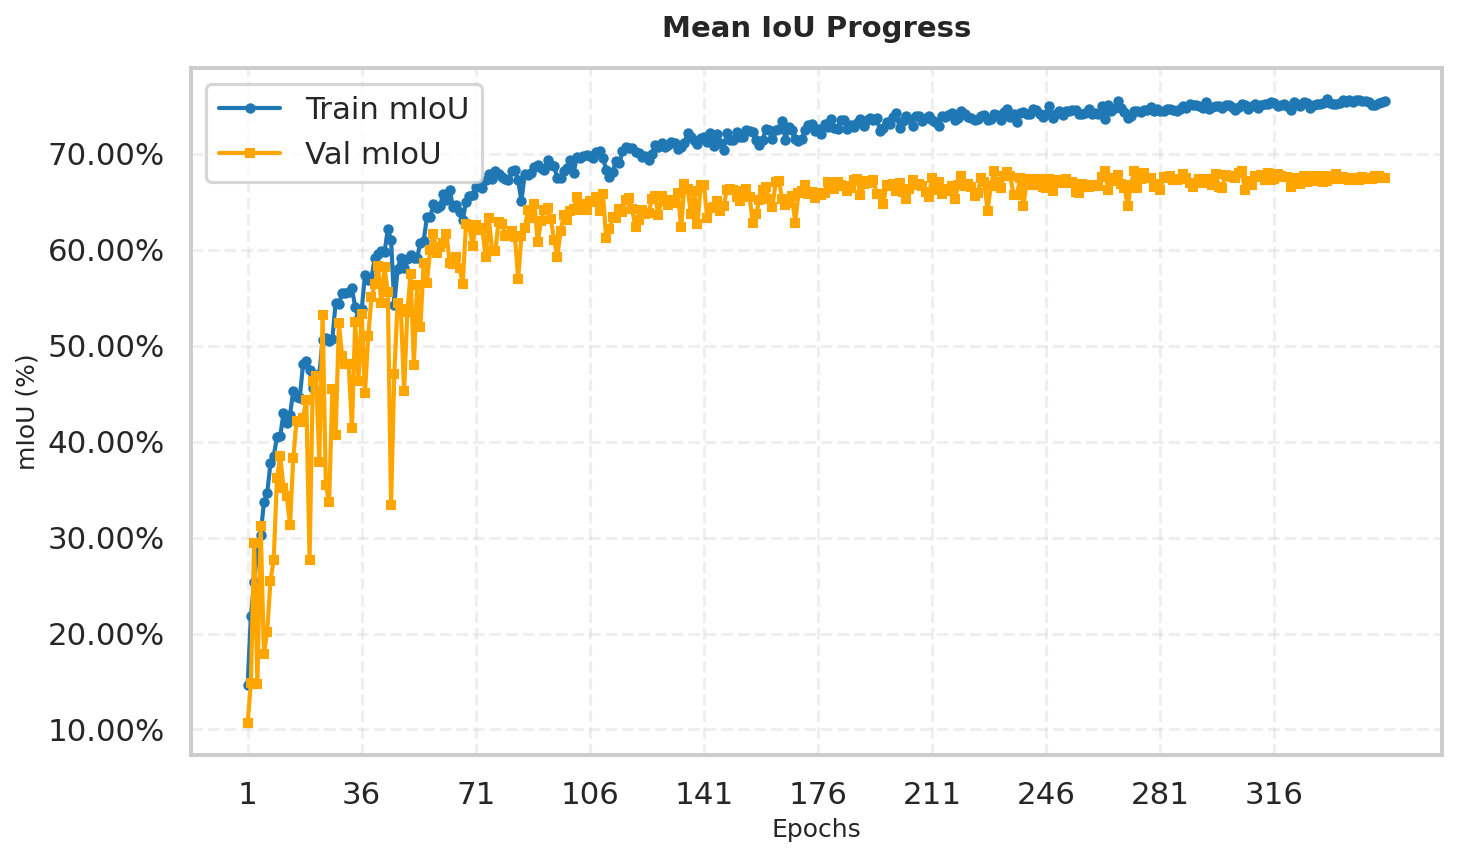

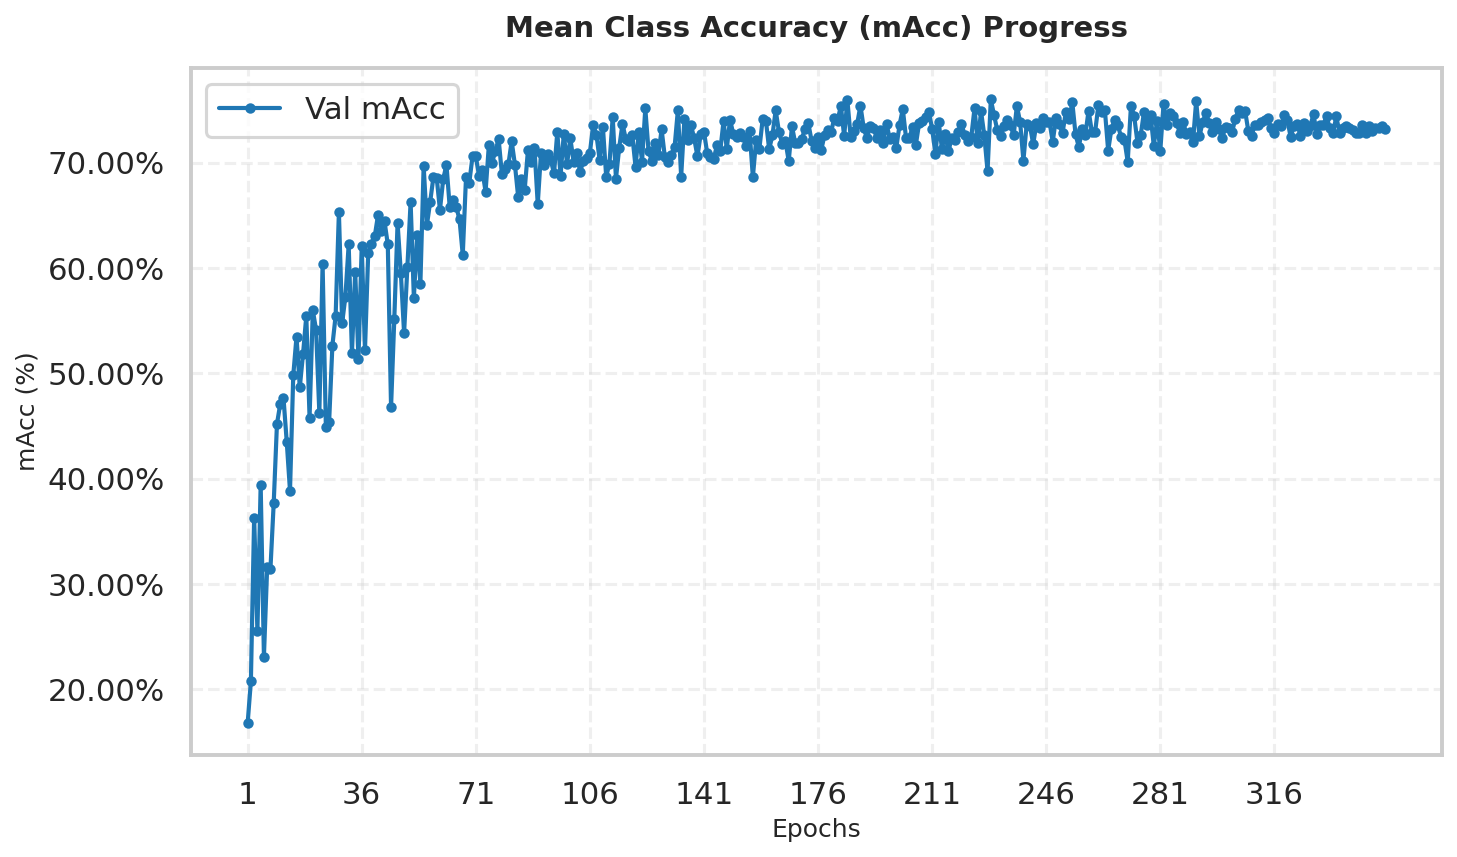

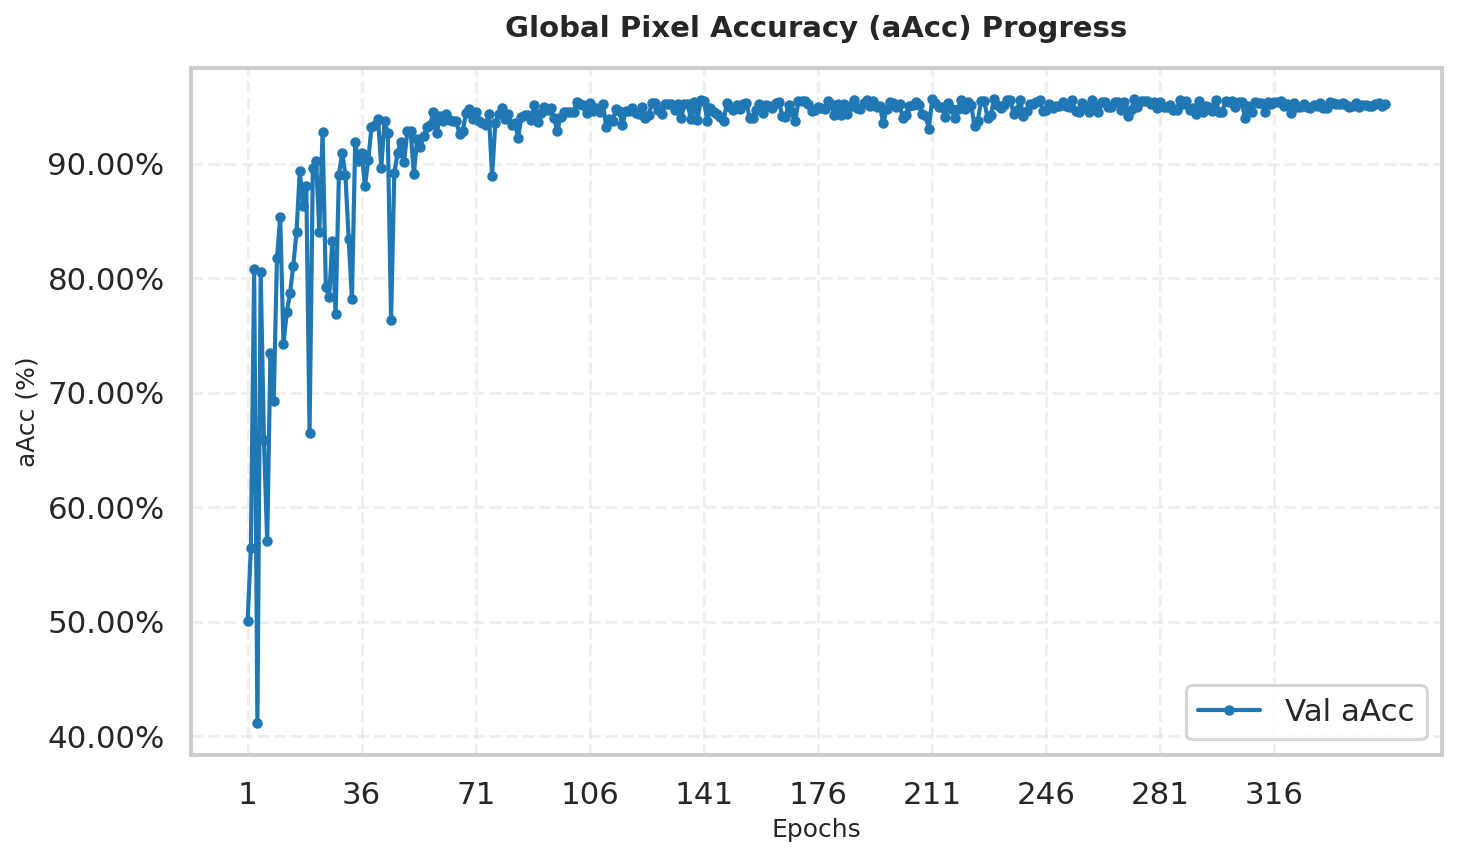

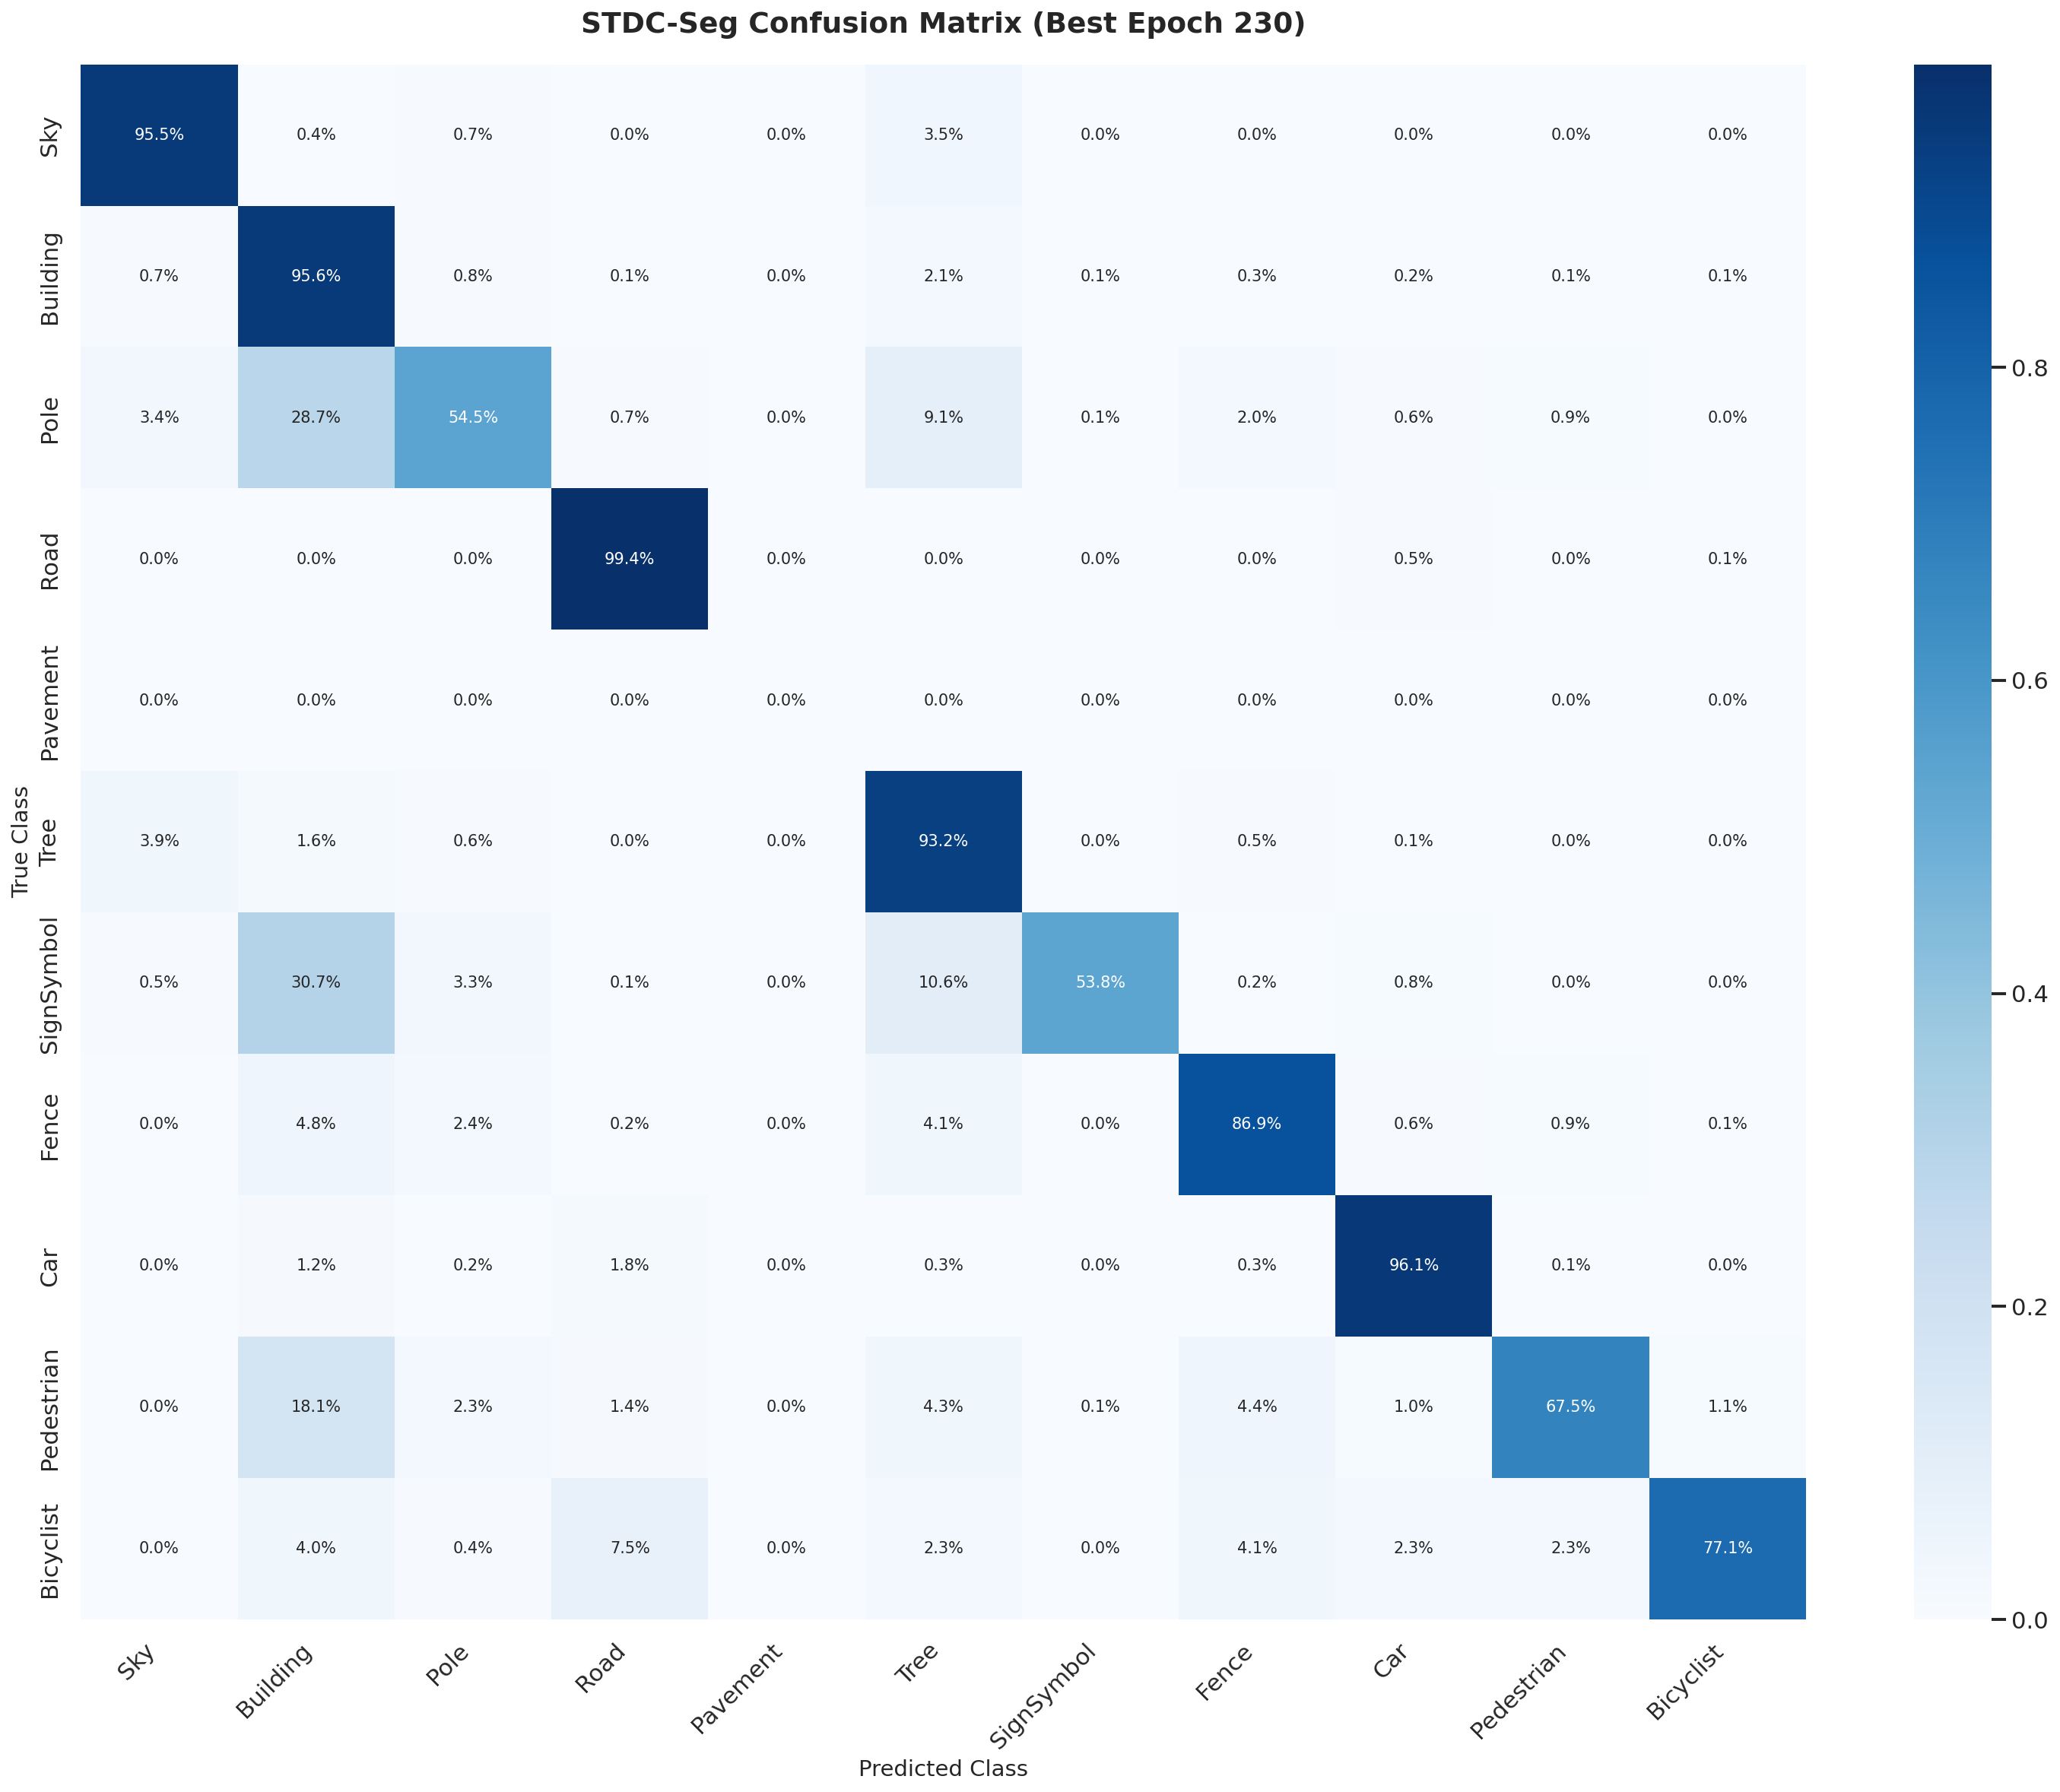


-------------------------------------------------------------------------------------
Architecture: STDC-Seg (Short-Term Dense Concatenate Network)
Loss Config: Semantic (OHEM Cross-Entropy) + Detail Guidance (BCE & Dice)
Total Parameters:      8,115,436  (8.12 M)
Trainable Parameters:  8,115,436  (8.12 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid

FINAL RESULTS (STDC-Seg Architecture)
Best Validation mIoU:             68.19% (Epoch 230)
Best Validation mAcc:             74.51%
Best Validation aAcc:             95.61%
Final Epoch Pixel Acc (aAcc):     95.20%
Final Epoch Mean Class Acc (mAcc):73.17%
Best Model F1-Score (Macro):      76.53%
Total Training Time:              1:53:26
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)      | F1-Score (%)   | Precision (%)  | Reca

In [8]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: STDC Network (STDC-Seg)
# Target Dataset: CamVid
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("~/Pictures/stdc_camvid/Results_Export_stdc_camvid").expanduser())
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", globals().get("val_conf_matrix", None))

if BEST_CONF_MATRIX is None and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    
    # Safely extract the path established in Step 1/5
    best_ckpt_path = best_record.get("best_path", os.path.join(CHECKPOINT_DIR, "best_miou_stdc_checkpoint.pt"))
    
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        # Detail branch is discarded during inference
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (TTA)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                # Multi-scale TTA simulation for robust evaluation
                scales = [0.75, 1.0, 1.25]
                final_logits = torch.zeros((images.shape[0], CLASSES, val_h, val_w), device=DEVICE, dtype=torch.float32)
                
                for scale in scales:
                    sH, sW = (int(val_h * scale) // 32) * 32, (int(val_w * scale) // 32) * 32 
                    scaled_img = F.interpolate(images, size=(sH, sW), mode='bilinear', align_corners=False)
                    
                    with torch.autocast(device_type="cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                        # STDC Evaluation Mode (Returns Single Segmentation Tensor)
                        logits = model(scaled_img)
                        logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=True)
                        final_logits += logits_up.float()
                        
                        flip_logits = model(torch.flip(scaled_img, dims=[3]))
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=True)
                        final_logits += torch.flip(flip_logits_up, dims=[3]).float()
                        
                semantic_logits = final_logits / (len(scales) * 2)
                
                preds = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                valid = (targets_np != IGNORE_INDEX)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print(f"[!] Could not locate best checkpoint at {best_ckpt_path}. Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))
if num_epochs == 0:
    num_epochs = len(history.get("train_total_loss", []))

def get_hist_col(key):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

# Matches exactly with what was tracked in STDC Step 5
df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_CE_Loss": get_hist_col("train_ce_loss"),
    "Train_Detail_Loss": get_hist_col("train_detail_loss"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

if df["Epoch"].isna().all() and num_epochs > 0:
    df["Epoch"] = list(range(1, num_epochs + 1))

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_aAcc = safe_pct(df["Val_aAcc"].iloc[-1]) if not df["Val_aAcc"].isna().all() else 0.0
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1]) if not df["Val_mAcc"].isna().all() else 0.0

# Extract the BEST metrics saved to the dictionary during Step 5
best_miou = safe_pct(best_record.get("best_miou", 0.0))
best_macc = safe_pct(best_record.get("best_macc", 0.0))
best_aacc = safe_pct(best_record.get("best_aacc", 0.0))
best_epoch = best_record.get("best_epoch", -1)

# Derive Macro averages from the Best Confusion matrix if available
if BEST_CONF_MATRIX is not None:
    best_macro_f1 = np.mean([item["F1-Score (%)"] for item in class_wise_data])
else:
    best_macro_f1 = 0.0

final_global_data = [
    {"Metric": "Best Validation mIoU", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Best Validation mAcc", "Value": f"{best_macc:.2f}%"},
    {"Metric": "Best Validation aAcc", "Value": f"{best_aacc:.2f}%"},
    {"Metric": "Final Epoch Pixel Accuracy (aAcc)", "Value": f"{final_aAcc:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mAcc:.2f}%"},
    {"Metric": "Best Model Macro F1-Score", "Value": f"{best_macro_f1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_stdc.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_STDC.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        step = max(1, len(epochs_range) // 10) # Dynamic X-axis spacing
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=step))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# 1. Overall Loss & Mechanics
save_separate_plot("loss_comparison", "Total Loss Comparison (Train vs Val)", "Total Loss", 
                   df["Train_Total_Loss"].tolist(), df["Val_Total_Loss"].tolist())
save_separate_plot("learning_rate_progress", "Poly LR + Warmup Schedule", "Learning Rate", 
                   df["Learning_Rate"].tolist(), label1="STDC LR")

# 2. STDC Split Losses (Detail vs Semantic)
save_separate_plot("stdc_loss_split", "STDC Sub-Losses: Semantic vs Detail Guidance", "Loss", 
                   df["Train_CE_Loss"].tolist(), df["Train_Detail_Loss"].tolist(), 
                   label1="Semantic Loss (OHEM CE)", label2="Detail Loss (BCE + Dice)")

# 3. Validation Metrics
save_separate_plot("miou_progress", "Mean IoU Progress", "mIoU (%)", 
                   df["Train_mIoU"].tolist(), df["Val_mIoU"].tolist(), 
                   label1="Train mIoU", label2="Val mIoU", is_percentage=True)
save_separate_plot("macc_progress", "Mean Class Accuracy (mAcc) Progress", "mAcc (%)", 
                   df["Val_mAcc"].tolist(), label1="Val mAcc", is_percentage=True)
save_separate_plot("aacc_progress", "Global Pixel Accuracy (aAcc) Progress", "aAcc (%)", 
                   df["Val_aAcc"].tolist(), label1="Val aAcc", is_percentage=True)

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"STDC-Seg Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: STDC-Seg (Short-Term Dense Concatenate Network)")
print(f"Loss Config: Semantic (OHEM Cross-Entropy) + Detail Guidance (BCE & Dice)")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (STDC-Seg Architecture)")
print("="*85)
print(f"Best Validation mIoU:             {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Best Validation mAcc:             {best_macc:.2f}%")
print(f"Best Validation aAcc:             {best_aacc:.2f}%")
print(f"Final Epoch Pixel Acc (aAcc):     {final_aAcc:.2f}%")
print(f"Final Epoch Mean Class Acc (mAcc):{final_mAcc:.2f}%")
print(f"Best Model F1-Score (Macro):      {best_macro_f1:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}")

[*] Presentation graph will be safely exported to:
/home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid/STDC_CamVid
[*] Success! Graph preserved at:
/home/ubuntu/Pictures/stdc_camvid/Results_Export_stdc_camvid/STDC_CamVid/presentation_metrics_STDC_CamVid.png


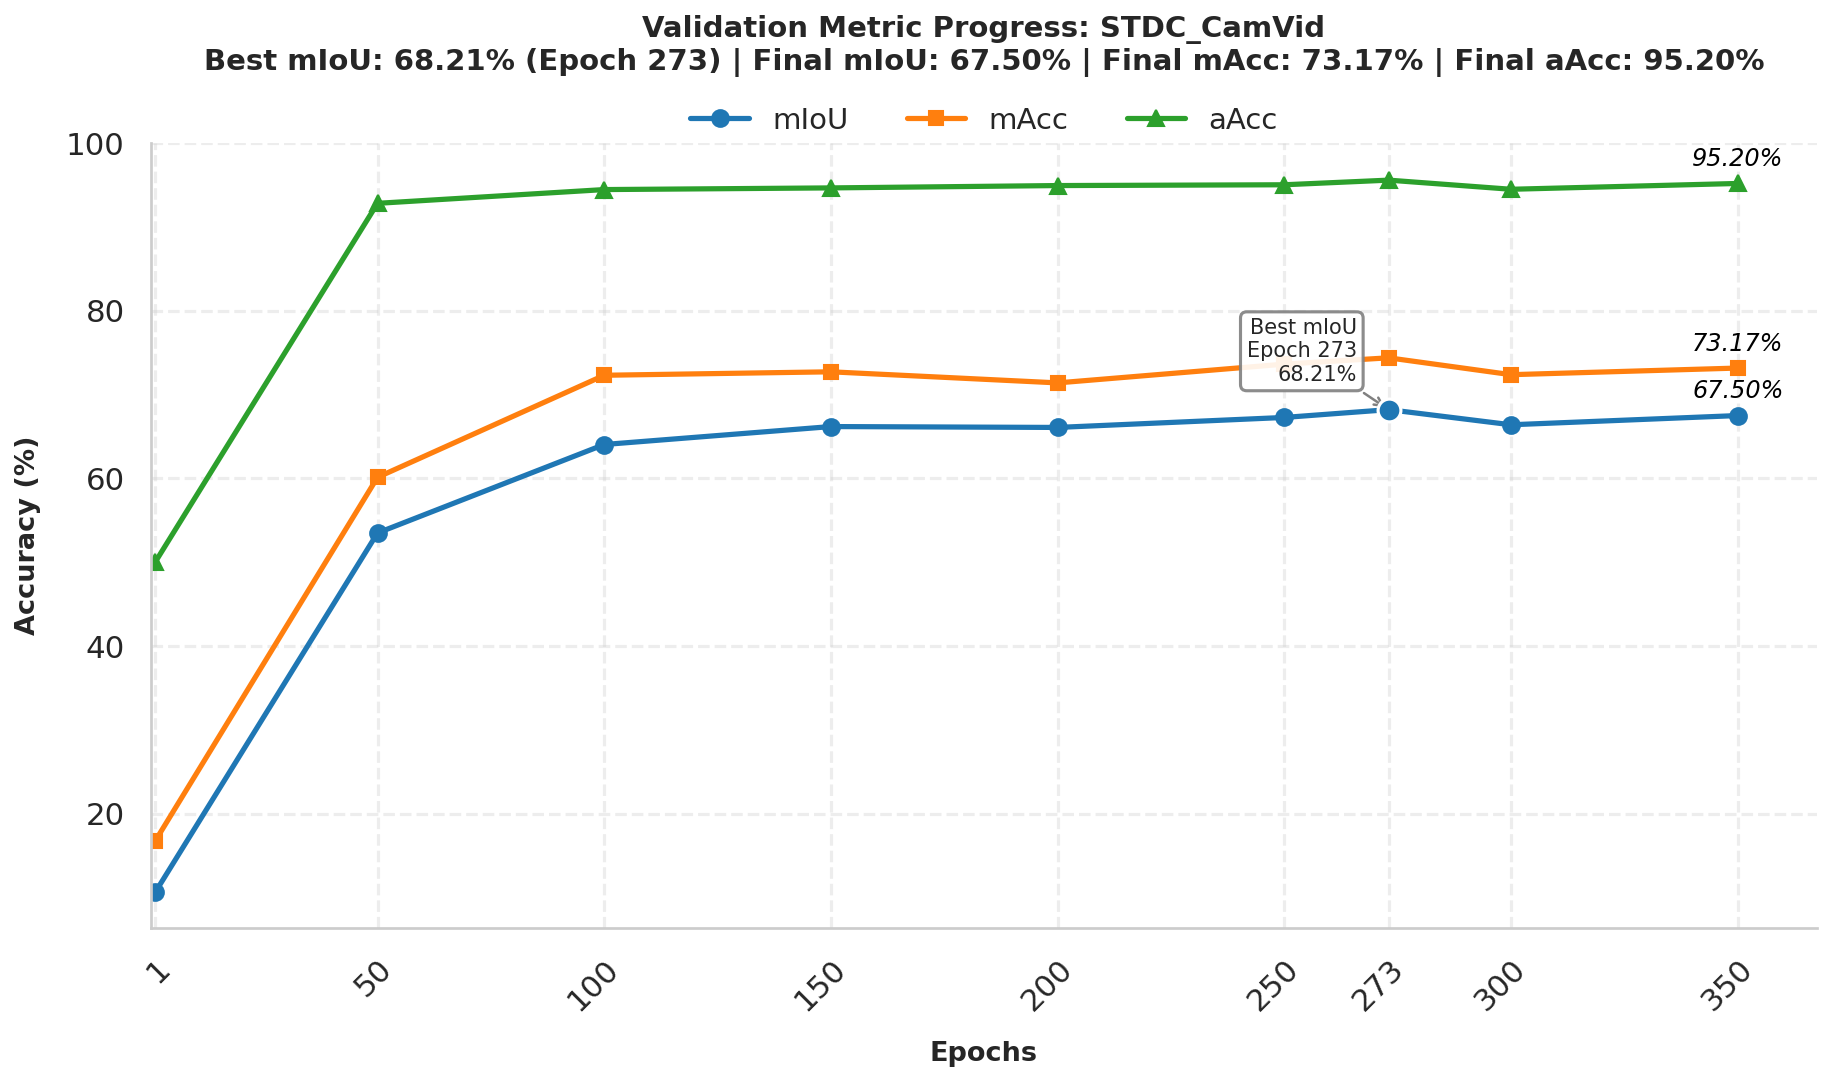

In [9]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: STDC Network (STDC-Seg)
# Target Dataset: CamVid
# Optimized for: Kernel Crash Recovery, Ablation Study Isolation, 
# Specific Epoch Intervals, and Strict Percentage Scaling
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 0) CRASH-PROOF RECOVERY (Handles Kernel Restarts)
# ------------------------------------------------------------
if "history" not in globals():
    print("[!] 'history' not found in memory. Attempting to load from disk...")
    CHECKPOINT_DIR = Path("~/Pictures/stdc_camvid/progressive_checkpoints_stdc_camvid").expanduser()
    
    # Try to load the latest checkpoint to get the most complete history
    latest_ckpt_path = CHECKPOINT_DIR / "latest_stdc_checkpoint.pt"
    best_ckpt_path = CHECKPOINT_DIR / "best_miou_stdc_checkpoint.pt"
    
    ckpt_to_load = latest_ckpt_path if latest_ckpt_path.exists() else best_ckpt_path
    
    if ckpt_to_load.exists():
        checkpoint = torch.load(ckpt_to_load, map_location="cpu", weights_only=False)
        history = checkpoint.get("history", {})
        print(f"[*] Successfully recovered 'history' from {ckpt_to_load.name}.")
    else:
        raise FileNotFoundError(f"[!] Could not find checkpoints in {CHECKPOINT_DIR}. Cannot recover 'history'.")

# ------------------------------------------------------------
# 1) SAFETY CHECKS & ABLATION PATH INHERITANCE
# ------------------------------------------------------------
if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training before Step 7.")

# Securely inherit the specific run directory and experiment name
EXPERIMENT_NAME = globals().get("EXPERIMENT_NAME", "STDC_CamVid")
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("~/Pictures/stdc_camvid/Results_Export_stdc_camvid").expanduser())
RUN_SAVE_DIR = globals().get("RUN_SAVE_DIR", MASTER_SAVE_DIR / EXPERIMENT_NAME)

# Ensure the directory exists just in case
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Presentation graph will be safely exported to:\n{RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# 2) PREPARE EPOCHS & DATA
# ------------------------------------------------------------
# Fallback generator if the explicit "epoch" list is missing from older checkpoints
num_epochs = len(history["val_miou"])
all_epochs = history.get("epoch", list(range(1, num_epochs + 1)))

# Safe percentage converter
def safe_pct(val):
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Filter epochs to reduce visual clutter: Epoch 1, every 50th epoch (due to 350+ epochs), best, final
step_size = 50 if num_epochs > 200 else 10
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % step_size == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# 3) PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# 4) AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ------------------------------------------------------------
# 5) BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + (max(filtered_epochs) * 0.02)
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - (max(filtered_epochs) * 0.02)
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 3.0),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# 6) END-OF-LINE FINAL VALUE ANNOTATIONS 
# ------------------------------------------------------------
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.05))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# 7) STYLING & LEGEND
# ------------------------------------------------------------
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

# Dynamically injecting the specific EXPERIMENT_NAME into the title
title_main = f"Validation Metric Progress: {EXPERIMENT_NAME}"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# 8) ISOLATED RUN SAVE
# ------------------------------------------------------------
combined_graph_path = RUN_SAVE_DIR / f"presentation_metrics_{EXPERIMENT_NAME}.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"[*] Success! Graph preserved at:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()